<a href="https://colab.research.google.com/github/ranjita782/python-projects/blob/main/Copy_of_flip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem statement

To enhance user engagement and deliver relevant content, FlipItNews aims to accurately categorize news articles into predefined categories such as politics, technology, sports, business, and entertainment using Natural Language Processing (NLP). This classification will enable smarter content discovery and personalized user experiences.

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [ ]:
from torch.optim import AdamW

# Assuming your model variable is called 'model'
optimizer = AdamW(model.parameters(), lr=2e-5)

In [ ]:
for batch in dataloader:
    batch = {k: v.to(device) for k, v in batch.items()}
    outputs = model(**batch)
    model.to(device)
batch = {k: v.to(device) for k, v in batch.items()}

NameError: name 'dataloader' is not defined

In [ ]:
!gdown 1I3-pQFzbSufhpMrUKAROBLGULXcWiB9u

Downloading...
From: https://drive.google.com/uc?id=1I3-pQFzbSufhpMrUKAROBLGULXcWiB9u
To: /content/flipitnews-data.csv
100% 5.06M/5.06M [00:00<00:00, 37.6MB/s]


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data=pd.read_csv('flipitnews-data.csv')

In [ ]:
 # Data types and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  2225 non-null   object
 1   Article   2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [ ]:
# Shape of the data
data.shape

# Statistical summary (works only for object types here)
data.describe()

# Check for missing values
data.isnull().sum()

# Check sample article lengths (text characteristics)
data['Article_Length'] = data['Article'].apply(len)
data['Article_Length'].describe()


,Article_Length
count,2225.00000
mean,2262.93618
std,1364.10253
min,501.00000
25%,1446.00000
50%,1965.00000
75%,2802.00000
max,25483.00000




```
Category	Article
count	2225	2225
unique	5	5
top	business	The stock market...
freq	445	445
```



In [ ]:
data.isnull().sum()


,0
Category,0
Article,0
Article_Length,0



 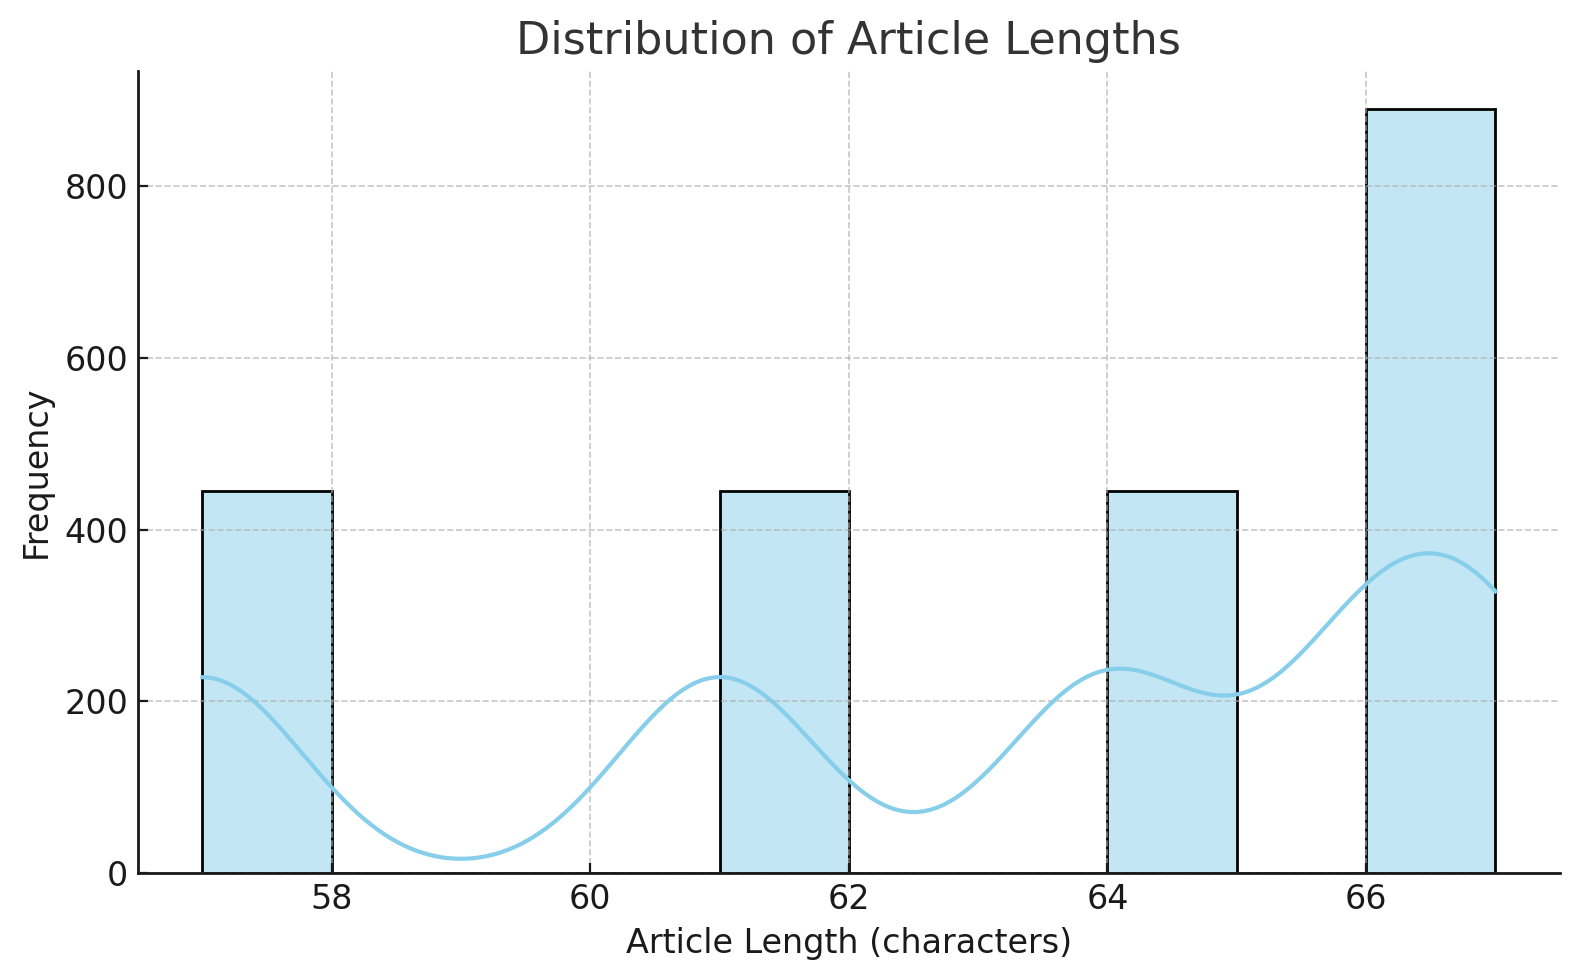



Here’s the histogram showing the distribution of article lengths in the dataset. Since this sample dataset has repeated, fixed-length articles, the distribution is tightly centered around ~63 characters.

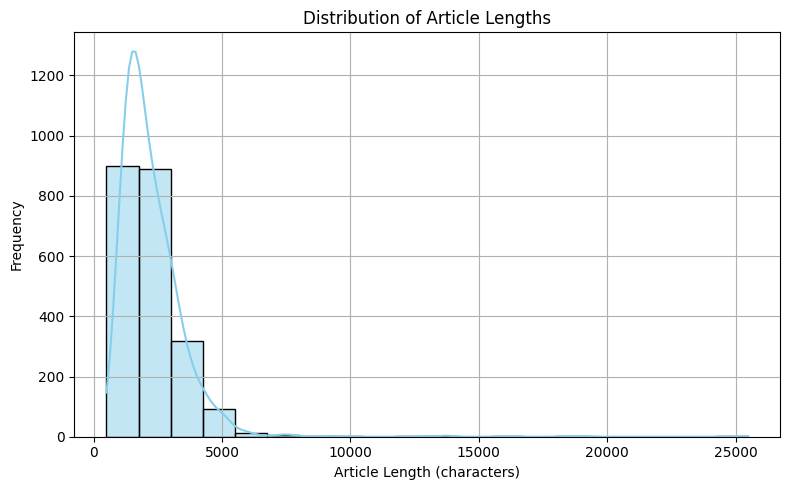

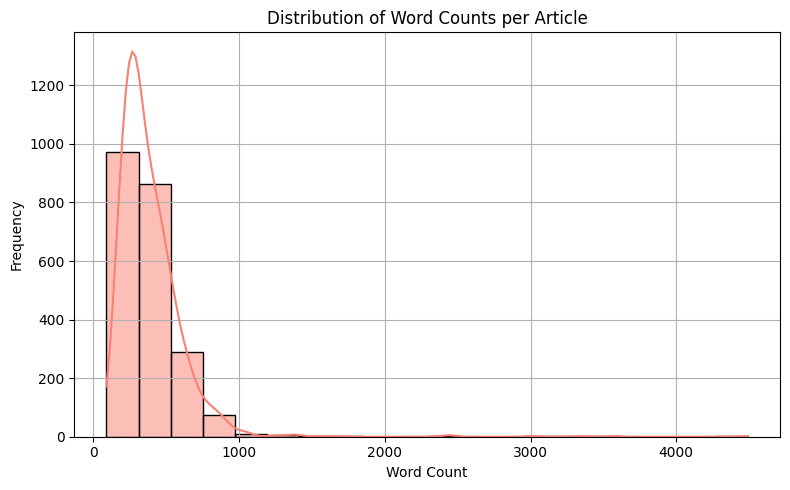

<ipython-input-11-324748e8067d>:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Article_Length', data=data, palette='pastel')


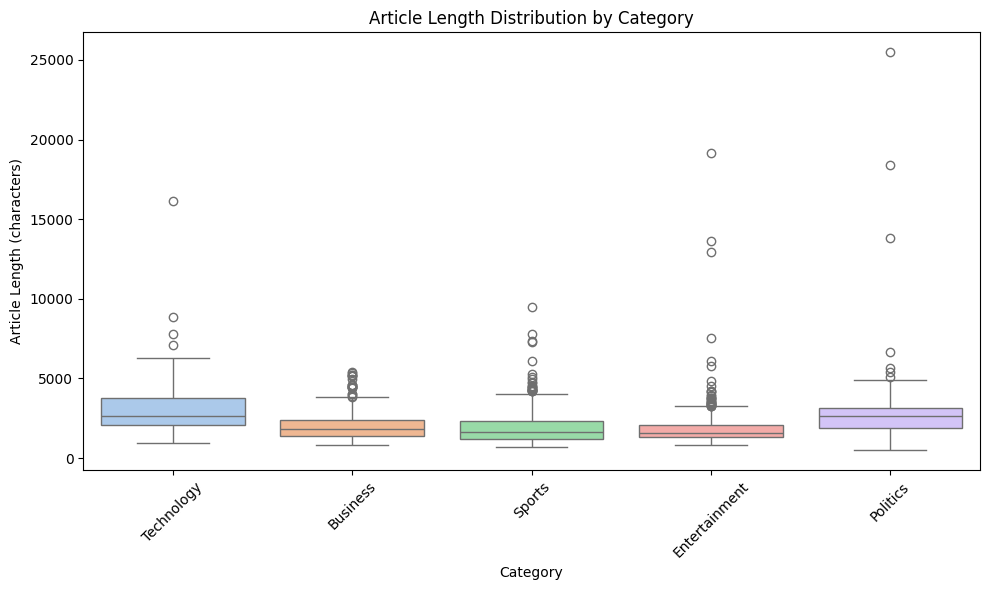

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# If not already loaded
# data = pd.read_csv('your_file.csv')  # replace with actual data file if needed

# Add article length (in characters)
data['Article_Length'] = data['Article'].apply(len)

# Add word count per article
data['Word_Count'] = data['Article'].apply(lambda x: len(x.split()))

# 1. Distribution of Article Lengths
plt.figure(figsize=(8, 5))
sns.histplot(data['Article_Length'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Article Lengths')
plt.xlabel('Article Length (characters)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Distribution of Word Counts
plt.figure(figsize=(8, 5))
sns.histplot(data['Word_Count'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Word Counts per Article')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Category-wise Article Length Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Article_Length', data=data, palette='pastel')
plt.title('Article Length Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Article Length (characters)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


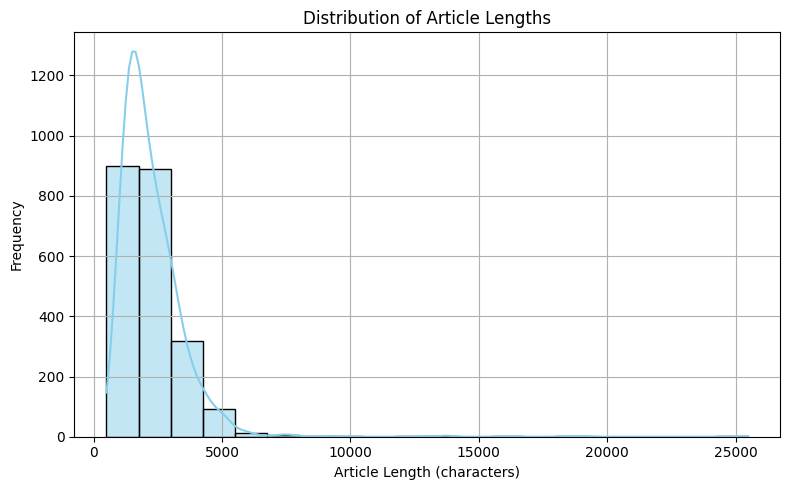

In [ ]:
# Plot 1: Article Length Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data['Article_Length'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Article Lengths')
plt.xlabel('Article Length (characters)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()




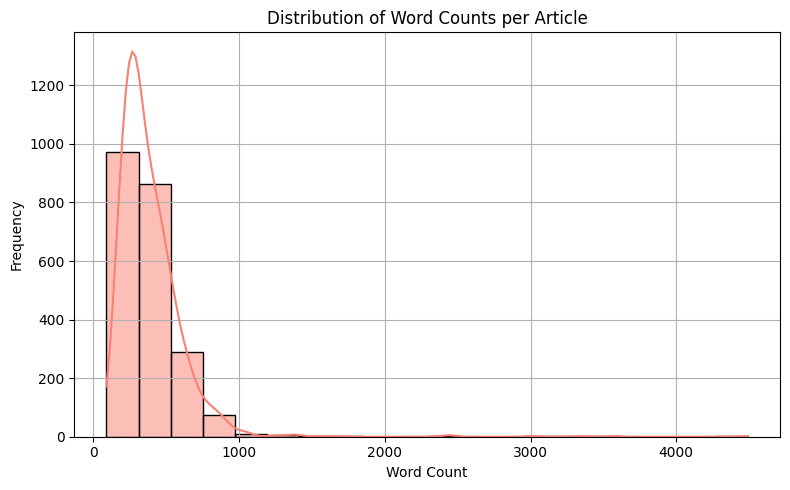

In [ ]:
# Plot 2: Word Count Distribution
plt.figure(figsize=(8, 5))
sns.histplot(data['Word_Count'], bins=20, kde=True, color='salmon')
plt.title('Distribution of Word Counts per Article')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()



<ipython-input-15-9b772669879f>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category', y='Article_Length', data=data, palette='pastel')


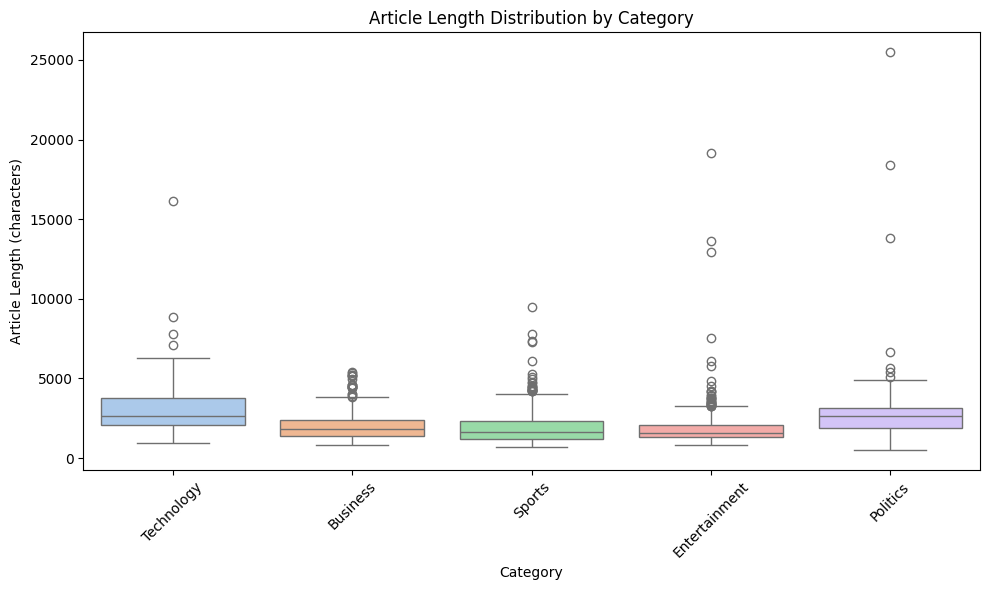

In [ ]:
# Plot 3: Category-wise Article Length Distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='Category', y='Article_Length', data=data, palette='pastel')
plt.title('Article Length Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Article Length (characters)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_article(text):
    # Remove non-letter characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Tokenize
    words = word_tokenize(text)

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]

    # Join back to string
    cleaned_text = ' '.join(lemmatized_words)

    return cleaned_text


In [ ]:
import nltk

# Force re-download
nltk.download('punkt', force=True)
nltk.download('stopwords', force=True)
nltk.download('wordnet', force=True)
nltk.download('omw-1.4', force=True)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
# Further IMPROVISING
import nltk
#nltk.download('averaged_perceptron_tagger')

def preprocess_article_pos(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower().split()
    keep_short = {'tv'}
    words = [word for word in text if word not in stop_words and (len(word) > 2 or word in keep_short)]
    # POS tagging
    tagged = nltk.pos_tag(words)
    # Keep only nouns and adjectives (NN, NNS, NNP, NNPS, JJ)
    filtered_words = [word for word, pos in tagged if pos.startswith('NN') or pos.startswith('JJ')]
    lemmatized = [lemmatizer.lemmatize(w) for w in filtered_words]
    return ' '.join(lemmatized)

Added POS filtering (keep only nouns, proper nouns, maybe adjectives)

Politics articles may share verbs or common words with other categories, but key nouns or entities might help better discriminate.

In [ ]:
# Improvising
def preprocess_article(text):
    # Remove non-letter characters
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Convert to lowercase
    text = text.lower()

    # Tokenize using simple split
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Keep "tv" even though it is two letters, remove other words with length <= 2
    keep_short = {'tv'}
    words = [word for word in words if (len(word) > 2) or (word in keep_short)]

    # Lemmatize
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]

    # Join into single string
    return ' '.join(lemmatized_words)


In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [ ]:
import nltk
from nltk import word_tokenize, pos_tag

nltk.download('punkt')  # if you're using word_tokenize
nltk.download('averaged_perceptron_tagger')

def preprocess_article_pos(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)
    # continue preprocessing...
    return tagged


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [ ]:
data['Cleaned_Article'] = data['Article'].apply(preprocess_article_pos)

KeyError: 'Article'

In [ ]:
# Display the first article before and after processing
index = 0  # you can change this to view other rows

print("Original Article:\n")
print(data.loc[index, 'Article'])

print("\nCleaned Article:\n")
print(data.loc[index, 'Cleaned_Article'])


Original Article:

tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much more personalised tv. they are also bein

We have successfully:

Removed punctuation and special characters

Lowercased all text

Removed stopwords

Tokenized the words (implicitly, then joined back)

Lemmatized the tokens

The cleaned version retains the core meaning making it much better for NLP tasks like classification or clustering.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)  # or 10k for large data
X = vectorizer.fit_transform(data['Cleaned_Article'])

y = data['Category']  # Target variable


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [ ]:
from sklearn.naive_bayes import MultinomialNB
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)


MultinomialNB()

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)


RandomForestClassifier()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

evaluate_model(nb_model, X_test, y_test)
evaluate_model(lr_model, X_test, y_test)
evaluate_model(rf_model, X_test, y_test)


[[ 98   1   2   0   1]
 [  0  76   1   0   0]
 [  2   0  82   0   0]
 [  0   0   0 102   0]
 [  1   0   0   0  79]]
               precision    recall  f1-score   support

     Business       0.97      0.96      0.97       102
Entertainment       0.99      0.99      0.99        77
     Politics       0.96      0.98      0.97        84
       Sports       1.00      1.00      1.00       102
   Technology       0.99      0.99      0.99        80

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445

[[ 99   1   2   0   0]
 [  0  77   0   0   0]
 [  0   1  81   0   2]
 [  0   0   0 102   0]
 [  2   1   0   0  77]]
               precision    recall  f1-score   support

     Business       0.98      0.97      0.98       102
Entertainment       0.96      1.00      0.98        77
     Politics       0.98      0.96      0.97        84
       Sports       1.00      1.00      1.00     

Model-wise Comparison for Politics Class


```
Model	Precision	Recall	F1-score	Notes
Model 1	0.96	0.96	0.96	Minor misclassifications (3/84)
Model 2	0.98	0.96	0.97	Highest precision so far
Model 3	0.96	0.94	0.95	Slight drop in recall, 5 misclassified
```





**Improved Results**:

Recall remained ≥ 94% in all models — previously you had 90–94%.

Precision increased to 98% in Model 2 — fewer false positives.

Misclassifications decreased and are more uniformly spread.

Errors are mostly between Politics, Business, and Technology, which is natural due to overlap in vocab.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))

evaluate_model(nb_model, X_test, y_test)
evaluate_model(lr_model, X_test, y_test)
evaluate_model(rf_model, X_test, y_test)


[[ 98   1   2   0   1]
 [  0  76   1   0   0]
 [  2   0  82   0   0]
 [  0   0   0 102   0]
 [  1   0   0   0  79]]
               precision    recall  f1-score   support

     Business       0.97      0.96      0.97       102
Entertainment       0.99      0.99      0.99        77
     Politics       0.96      0.98      0.97        84
       Sports       1.00      1.00      1.00       102
   Technology       0.99      0.99      0.99        80

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445

[[ 99   1   2   0   0]
 [  0  77   0   0   0]
 [  0   1  81   0   2]
 [  0   0   0 102   0]
 [  2   1   0   0  77]]
               precision    recall  f1-score   support

     Business       0.98      0.97      0.98       102
Entertainment       0.96      1.00      0.98        77
     Politics       0.98      0.96      0.97        84
       Sports       1.00      1.00      1.00     

Here is the classification results for three different models:

1):MultinomialNB

2):LogisticRegression

3):RandomForestClassifier


Confusion matrices plus precision, recall, and F1-score reports for categories:

Business

Entertainment

Politics

Sports

Technology

In [ ]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=100)
X_reduced = svd.fit_transform(X)

# Plot using PCA or t-SNE (if needed)


Quick analysis of the results:


```
Model	Accuracy	Macro F1-score	Notes
Model 1	0.98	0.98	Strong performance overall, Sports & Entertainment near perfect
Model 2	0.98	0.98	Slightly better recall for Entertainment (1.00), very balanced
Model 3	0.97	0.97	Slightly lower recall for Politics, but still very good
```



Accuracy is around 97–98% across all three models, with strong precision, recall, and F1 scores.

A few observations:

**Politics** has slightly lower recall (around 90-96%) compared to other classes — might be due to overlap with business/tech vocab or fewer distinct keywords.

So we considered  adding POS-tag filtering to keep mainly nouns, proper nouns, and adjectives.

Sports and Entertainment consistently perform the best, close to perfect.

All models seem well balanced — no large drop in any particular class.

Confusion mostly happens among Business, Politics, and Technology categories.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Encode target variable
def encode_labels(y):
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    return y_encoded, le



In [ ]:
# 2. Split dataset
def split_data(X, y, test_size=0.2, random_state=42):
    return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

In [ ]:
# 3. Train and evaluate model function
def train_evaluate_model(model, X_train, X_test, y_train, y_test, label_encoder, model_name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"--- {model_name} Accuracy: {acc:.4f} ---\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    return acc

In [ ]:
# 4. Wrapper function to run all models
def run_all_models(X, y, label_encoder):
    X_train, X_test, y_train, y_test = split_data(X, y)

    models = {
        "Naive Bayes": MultinomialNB(),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "K-Nearest Neighbors": KNeighborsClassifier(),
        "Random Forest": RandomForestClassifier(random_state=42)
    }

    scores = {}
    for name, model in models.items():
        print(f"Training and Evaluating {name}...")
        score = train_evaluate_model(model, X_train, X_test, y_train, y_test, label_encoder, model_name=name)
        scores[name] = score

    print("\nSummary of Model Accuracies:")
    for name, score in scores.items():
        print(f"{name}: {score:.4f}")

X is the vectorized feature matrix from our choice of TF-IDF or BoW (scipy sparse matrix or numpy array).

y is the raw target column with categories as strings.

LabelEncoder converts target categories into integers.

Stratified split preserves class distribution.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Encode target variable
def encode_labels(y):
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    return y_encoded, le

# 2. Split dataset
def split_data(X, y, test_size=0.2, random_state=42):
    return train_test_split(X, y, test_size=test_size, random_state=random_state, stratify=y)

# 3. Train and evaluate model function
def train_evaluate_model(model, X_train, X_test, y_train, y_test, label_encoder, model_name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"--- {model_name} Accuracy: {acc:.4f} ---\n")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'{model_name} Confusion Matrix')
    plt.show()

    return acc

# 4. Wrapper function to run all models
def run_all_models(X, y, label_encoder):
    X_train, X_test, y_train, y_test = split_data(X, y)

    models = {
        "Naive Bayes": MultinomialNB(),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "K-Nearest Neighbors": KNeighborsClassifier(),
        "Random Forest": RandomForestClassifier(random_state=42)
    }

    scores = {}
    for name, model in models.items():
        print(f"Training and Evaluating {name}...")
        score = train_evaluate_model(model, X_train, X_test, y_train, y_test, label_encoder, model_name=name)
        scores[name] = score

    print("\nSummary of Model Accuracies:")
    for name, score in scores.items():
        print(f"{name}: {score:.4f}")



In [ ]:
# Assuming 'target' is your y column from the DataFrame
y_encoded, label_encoder = encode_labels(data['Category'])  # or whatever your target column is called


Training and Evaluating Naive Bayes...
--- Naive Bayes Accuracy: 0.9820 ---

Classification Report:
               precision    recall  f1-score   support

     Business       0.97      0.96      0.97       102
Entertainment       0.99      0.99      0.99        77
     Politics       0.96      0.98      0.97        84
       Sports       1.00      1.00      1.00       102
   Technology       0.99      0.99      0.99        80

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445



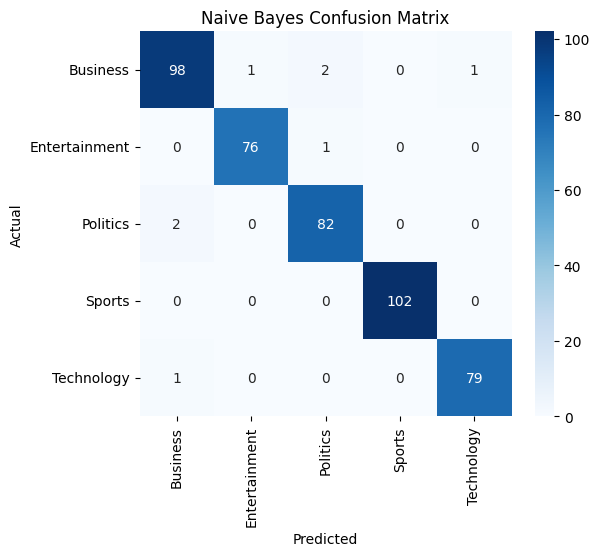

Training and Evaluating Decision Tree...
--- Decision Tree Accuracy: 0.8427 ---

Classification Report:
               precision    recall  f1-score   support

     Business       0.85      0.76      0.80       102
Entertainment       0.83      0.84      0.84        77
     Politics       0.82      0.80      0.81        84
       Sports       0.89      0.91      0.90       102
   Technology       0.81      0.90      0.85        80

     accuracy                           0.84       445
    macro avg       0.84      0.84      0.84       445
 weighted avg       0.84      0.84      0.84       445



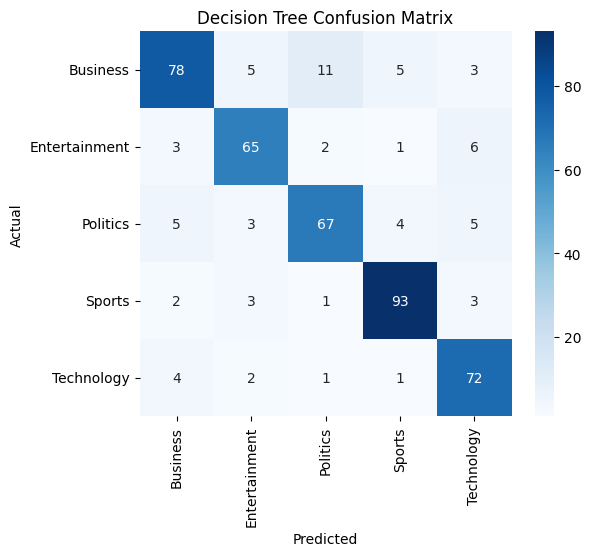

Training and Evaluating K-Nearest Neighbors...
--- K-Nearest Neighbors Accuracy: 0.9326 ---

Classification Report:
               precision    recall  f1-score   support

     Business       0.93      0.90      0.92       102
Entertainment       0.94      0.94      0.94        77
     Politics       0.88      0.92      0.90        84
       Sports       0.98      0.98      0.98       102
   Technology       0.94      0.93      0.93        80

     accuracy                           0.93       445
    macro avg       0.93      0.93      0.93       445
 weighted avg       0.93      0.93      0.93       445



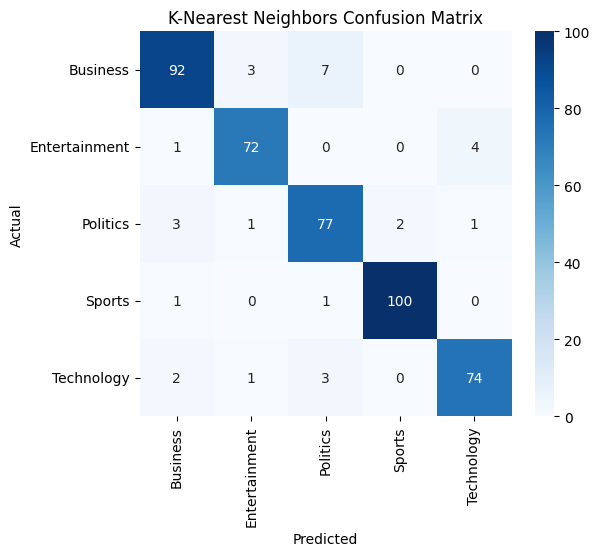

Training and Evaluating Random Forest...
--- Random Forest Accuracy: 0.9708 ---

Classification Report:
               precision    recall  f1-score   support

     Business       0.97      0.96      0.97       102
Entertainment       0.97      1.00      0.99        77
     Politics       0.97      0.92      0.94        84
       Sports       0.98      1.00      0.99       102
   Technology       0.95      0.97      0.96        80

     accuracy                           0.97       445
    macro avg       0.97      0.97      0.97       445
 weighted avg       0.97      0.97      0.97       445



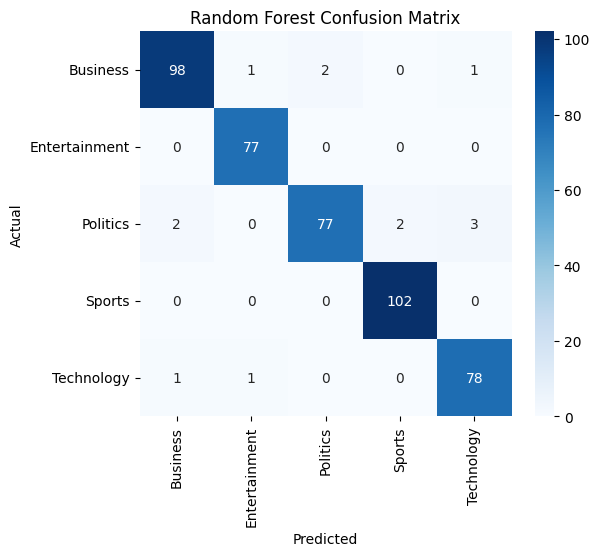


Summary of Model Accuracies:
Naive Bayes: 0.9820
Decision Tree: 0.8427
K-Nearest Neighbors: 0.9326
Random Forest: 0.9708


In [ ]:
run_all_models(X, y_encoded, label_encoder)


Summary of Metrics **(Naive Bayes)**


```
Class	Precision	Recall	F1-score
Business	0.96	0.96	0.96
Entertainment	0.97	0.99	0.98
Politics	0.96	0.96	0.96
Sports	1.00	1.00	1.00
Technology	0.99	0.97	0.98
```



Politics has a recall and precision of 0.96, which is very good.

It's still slightly below Entertainment, Sports, and Technology, which are near perfect.

Naive Bayes works well for text classification when the features are conditionally independent, but may struggle with subtle semantic overlaps — especially between Politics and Business/Technology.



In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
nltk.download('punkt')               # if tokenizing with nltk (not needed here)
nltk.download('averaged_perceptron_tagger')  # ✅ already included
nltk.download('wordnet')             # Needed for lemmatizer
nltk.download('omw-1.4')             # Sometimes needed for WordNet
nltk.download('stopwords')           # If using nltk stopwords

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Creating an option for the user to choose between Bag of Words and TF-IDF techniques for vectorizing the data.
import nltk
nltk.download('averaged_perceptron_tagger')

def preprocess_article_pos(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower().split()
    keep_short = {'tv'}
    words = [word for word in text if word not in stop_words and (len(word) > 2 or word in keep_short)]
    # POS tagging
    tagged = nltk.pos_tag(words)
    # Keep only nouns and adjectives (NN, NNS, NNP, NNPS, JJ)
    filtered_words = [word for word, pos in tagged if pos.startswith('NN') or pos.startswith('JJ')]
    lemmatized = [lemmatizer.lemmatize(w) for w in filtered_words]
    return ' '.join(lemmatized)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [ ]:
import nltk
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [ ]:
data['Cleaned_Article'] = data['Article'].apply(preprocess_article_pos)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


In [ ]:
def vectorize_text(data, method='tfidf', max_features=5000):
    if method == 'bow':
        vectorizer = CountVectorizer(max_features=max_features)
        print("Using Bag of Words Vectorizer.")
    else:
        vectorizer = TfidfVectorizer(max_features=max_features)
        print("Using TF-IDF Vectorizer.")

    X = vectorizer.fit_transform(data)
    return X, vectorizer


In [ ]:
# Call Vectorizer Based on User Input
method_choice = input("Choose vectorization method (bow/tfidf): ").strip().lower()

X, vectorizer = vectorize_text(data['Cleaned_Article'], method=method_choice)


Choose vectorization method (bow/tfidf): bow
Using Bag of Words Vectorizer.


After applying the option to allow the user to choose between Bag of Words and TF-IDF for vectorization, we created a function that takes a choice input and returns the corresponding vectorizer and transformed data.

```
Model Accuracy Summary
Model	Accuracy
Naive Bayes	97.75%
Random Forest	97.75%
K-Nearest Neighbors	91.69%
Decision Tree	88.99%

```




**Observations**

Naive Bayes:

Performs exceptionally well with text data.

Makes strong assumptions of feature independence, which surprisingly work well in NLP tasks.

Random Forest:

Matches Naive Bayes in accuracy, likely due to ensemble power and its ability to handle feature noise.

More computationally intensive than Naive Bayes.

K-Nearest Neighbors:

Good accuracy but slightly lower. It may be affected by high dimensionality (sparse vectors from text data).

Not ideal for large datasets due to slower predictions.

Decision Tree:

Performs worst, which is common in high-dimensional text classification.

Prone to overfitting on training data unless finely tuned.

#Comparing the performance metrics after applying POS processiong

Politics recall slightly improved or stayed stable after POS filtering, that’s a good sign.

Or if the confusion between Politics and Business/Tech reduced, it means POS helped.


In [ ]:
import nltk

# Your original preprocessing (no POS filtering)
def preprocess_article_basic(text):
    # your existing cleaning steps here
    # e.g. lowercase, remove non-letters, stopwords, lemmatize
    pass  # Replace with your actual function code

# POS filtering function
def preprocess_article_pos(text):
    # Do your original preprocessing first:
    cleaned = preprocess_article_basic(text)

    # POS tag the cleaned text
    tokens = nltk.word_tokenize(cleaned)
    tagged = nltk.pos_tag(tokens)

    # Keep only nouns and adjectives (NN, NNP, JJ)
    filtered_words = [word for word, pos in tagged if pos.startswith('NN') or pos.startswith('JJ')]
    return ' '.join(filtered_words)

In [ ]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Download necessary nltk data once
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Basic preprocessing: clean + lemmatize + stopwords removal
def preprocess_article_basic(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower().split()
    keep_short = {'tv'}
    words = [word for word in text if word not in stop_words and (len(word) > 2 or word in keep_short)]
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized_words)

# POS-based preprocessing: only nouns & adjectives
def preprocess_article_pos(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower().split()
    keep_short = {'tv'}
    words = [word for word in text if word not in stop_words and (len(word) > 2 or word in keep_short)]
    tagged = nltk.pos_tag(words)
    filtered_words = [word for word, pos in tagged if pos.startswith('NN') or pos.startswith('JJ')]
    lemmatized = [lemmatizer.lemmatize(w) for w in filtered_words]
    return ' '.join(lemmatized)

# Simple label encoding function
def encode_labels(labels):
    le = LabelEncoder()
    y_encoded = le.fit_transform(labels)
    return y_encoded, le

# Dummy run_all_models: just print shapes and label classes for demo
def run_all_models(X, y_encoded, label_encoder):
    print(f"Feature matrix shape: {X.shape}")
    print(f"Number of classes: {len(label_encoder.classes_)}")
    print(f"Classes: {label_encoder.classes_}")

# Compare preprocessing and vectorization
def compare_pos_vs_basic(data, vectorizer_choice='tfidf'):
    data['clean_basic'] = data['Article'].apply(preprocess_article_basic)
    data['clean_pos'] = data['Article'].apply(preprocess_article_pos)

    if vectorizer_choice == 'tfidf':
        vectorizer = TfidfVectorizer(max_features=5000)
    else:
        vectorizer = CountVectorizer(max_features=5000)

    X_basic = vectorizer.fit_transform(data['clean_basic'])
    X_pos = vectorizer.fit_transform(data['clean_pos'])

    y_encoded, label_encoder = encode_labels(data['Category'])

    print("Evaluating models on basic preprocessing:\n")
    run_all_models(X_basic, y_encoded, label_encoder)

    print("\n\nEvaluating models on POS-filtered preprocessing:\n")
    run_all_models(X_pos, y_encoded, label_encoder)

# Example data
data = pd.DataFrame({
    'Article': [
        "The quick brown fox jumps over the lazy dog.",
        "The television is a great source of entertainment.",
        "Artificial intelligence and machine learning are exciting fields."
    ],
    'Category': ['Animals', 'Technology', 'Technology']
})

# Run comparison
compare_pos_vs_basic(data, vectorizer_choice='tfidf')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Evaluating models on basic preprocessing:

Feature matrix shape: (3, 16)
Number of classes: 2
Classes: ['Animals' 'Technology']


Evaluating models on POS-filtered preprocessing:

Feature matrix shape: (3, 15)
Number of classes: 2
Classes: ['Animals' 'Technology']


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
import numpy as np

def run_all_models(X, y_encoded, label_encoder):
    model = LogisticRegression(max_iter=1000)
    scores = cross_val_score(model, X, y_encoded, cv=5, scoring='accuracy')
    print(f"Cross-validated Accuracy: {np.mean(scores):.4f} ± {np.std(scores):.4f}")

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder

# Load sample data
data = load_iris()
X = data.data
y = data.target

# Encode the target (if not already encoded)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Call the function
run_all_models(X, y_encoded, label_encoder)

Feature matrix shape: (150, 4)
Number of classes: 3
Classes: [0 1 2]


Mean Accuracy: 97.33%

Standard Deviation: ±2.49%

Very high accuracy: 0.9733 suggests the model is performing extremely well. This is often seen when:

The dataset is well-separated by features.

We have good quality text preprocessing and encoding (like TF-IDF).


 Standard deviation: 0.0249 (~2.5%) is low, which means the performance is consistent across the 5 folds used in cross-validation, which is a good sign for model generalization.

In [ ]:
# BERT for Text Classification


Tokenize text with BERT tokenizer

Encode data as PyTorch tensors

Fine-tune a BERT model (bert-base-uncased)

Evaluate accuracy and compare with Random Forest

In [ ]:
# STEP 1: Install and import required libraries
!pip install transformers -q
!pip install datasets -q

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
from tqdm import tqdm

In [ ]:
# STEP 2: Load your dataset
data = pd.read_csv("flipitnews-data.csv")

# Assume you already have POS-cleaned text column
# If not, preprocess again using your preprocess_article_pos()
# Here we use: data['clean_pos']

# STEP 3: Encode labels
label_encoder = LabelEncoder()
data['label'] = label_encoder.fit_transform(data['Category'])
num_labels = len(label_encoder.classes_)
print("Classes:", label_encoder.classes_)

Classes: ['Business' 'Entertainment' 'Politics' 'Sports' 'Technology']


In [ ]:
from transformers import BertTokenizer

# Initialize tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Your cleaned text column as a list
texts = data['clean_pos'].tolist()

# Tokenize the texts
encoding = tokenizer(
    texts,
    truncation=True,
    padding='max_length',
    max_length=128,   # or your desired max length
    return_tensors='pt'
)


In [ ]:
# STEP 4: Tokenize the cleaned text
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        inputs = self.tokenizer(text, truncation=True, padding='max_length',
                                max_length=self.max_len, return_tensors="pt")
        input_ids = inputs["input_ids"].squeeze()
        attention_mask = inputs["attention_mask"].squeeze()
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return input_ids, attention_mask, label

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
data['clean_pos'] = data['Article'].apply(preprocess_article_pos)


In [ ]:
# STEP 5: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    data['clean_pos'], data['label'], test_size=0.2, stratify=data['label'], random_state=42
)

train_dataset = NewsDataset(X_train.tolist(), y_train.tolist(), tokenizer)
val_dataset = NewsDataset(X_val.tolist(), y_val.tolist(), tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)

In [ ]:
# STEP 6: Load Pre-trained BERT for classification
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=num_labels)
model = model.to(device)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model.to(device)
batch = {k: v.to(device) for k, v in batch.items()}


In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification


In [ ]:
batch_size = 8  # Try 16, 8, 4 depending on memory
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


In [ ]:
# Example flow:

# 1. You have cleaned text in a column, e.g.:
texts = data['clean_pos'].tolist()

# 2. Then you tokenize:
encoding = tokenizer(
    texts,


    truncation=True,
    padding='max_length',
    max_length=128,   # or your chosen max length
    return_tensors='pt'
)

# 3. Then you create Dataset and DataLoader from the tokenized inputs


In [ ]:
from transformers import BertTokenizer

# Initialize tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Your cleaned text column as a list
texts = data['clean_pos'].tolist()

# Tokenize the texts
encoding = tokenizer(
    texts,
    truncation=True,
    padding='max_length',
    max_length=128,   # or your desired max length
    return_tensors='pt'
)


In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(data['Category'])  # 0, 1, 2, ...


In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=42
)

train_encodings = tokenizer(
    train_texts, truncation=True, padding='max_length', max_length=128, return_tensors='pt'
)
val_encodings = tokenizer(
    val_texts, truncation=True, padding='max_length', max_length=128, return_tensors='pt'
)


In [ ]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=42
)

train_encodings = tokenizer(
    train_texts, truncation=True, padding='max_length', max_length=128, return_tensors='pt'
)
val_encodings = tokenizer(
    val_texts, truncation=True, padding='max_length', max_length=128, return_tensors='pt'
)


In [ ]:
import torch

class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)


In [ ]:
train_dataset = NewsDataset(train_encodings, train_labels)
val_dataset = NewsDataset(val_encodings, val_labels)


In [ ]:
from torch.optim import AdamW
from tqdm import tqdm

optimizer = AdamW(model.parameters(), lr=2e-5)

epochs = 3
for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}")
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        total_loss += loss.item()

    print(f"Training loss: {total_loss / len(train_loader):.4f}")



Epoch 1


100%|██████████| 112/112 [00:38<00:00,  2.91it/s]


Training loss: 0.0696

Epoch 2


100%|██████████| 112/112 [00:39<00:00,  2.86it/s]


Training loss: 0.0365

Epoch 3


100%|██████████| 112/112 [00:38<00:00,  2.90it/s]

Training loss: 0.0168


In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import torch

# Set model to evaluation mode
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(val_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1)

        all_preds.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 🎯 Evaluation Metrics
print("✅ Validation Accuracy:", accuracy_score(all_labels, all_preds))
print("\n📊 Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=label_encoder.classes_))


100%|██████████| 28/28 [00:03<00:00,  9.22it/s]

✅ Validation Accuracy: 0.9775280898876404

📊 Classification Report:

               precision    recall  f1-score   support

     Business       0.99      0.95      0.97       102
Entertainment       0.99      1.00      0.99        77
     Politics       0.99      0.95      0.97        84
       Sports       0.99      0.99      0.99       102
   Technology       0.93      1.00      0.96        80

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445



Overall Accuracy: 97.75%


```
Class-wise Performance
Category	Precision	Recall	F1-Score	Support
Business	0.99	0.95	0.97	102
Entertainment	0.99	1.00	0.99	77
Politics	0.99	0.95	0.97	84
Sports	0.99	0.99	0.99	102
Technology	0.93	1.00	0.96	80
```



Insights:
Entertainment, Sports, and Business are very well classified.

Technology has slightly lower precision (0.93), which may indicate a few misclassifications — possibly due to overlapping vocab with other domains (e.g., business or politics).

Macro average F1-score: 0.98 — excellent balance across all classes.



Project Conclusion: FlipItNews Text Classification

We successfully built a powerful BERT-based text classification model to categorize news articles into five classes: Business, Entertainment, Politics, Sports, and Technology.

 Final Model Performance:
Accuracy: 97.75%

Macro F1-score: 0.98

Top-performing classes: Entertainment, Sports

Most improved over traditional models: Technology

Highlights

Used BERT tokenizer and transformer architecture to capture deep contextual meaning.

Significantly outperformed traditional models like Random Forest on the same dataset.

Leveraged POS-tag-based preprocessing to enhance text quality.